# AG-HYPOPT · Trial 19

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Eighteen trials. Best: **trial_13** `cvm_fwhm` **0.0733** (sw 0.1910). The `cvm_fwhm` series (eight points,
sw 0.18-0.38) averages ~0.0774 with every point at or under the KDE control (0.080328), so the family's
edge is broad in sw and is the loss form (KDE does not improve at the basin sw). All other families sit
above the control at matched sw (`kde` 0.083-0.087, `w1_2d` 0.0849, `w1_fwhm` 0.0923, `energy_2d` 0.1021,
`mmd_2d` 0.1755). Remaining trials refine the winner. No divergences. Phase `trials` (18/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_19'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (18/5 trials)
ID |     ei | params
 1 | 1.2559 | {"loss_family": "w1_fwhm", "sigma_weight": 0.23942569112963166}
 2 | 0.8462 | {"loss_family": "kde", "sigma_weight": 0.17387903179092204}
 3 | 3.0055 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20304511874259795}
 4 | 2.2661 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.24075558893955815}
 5 | 1.3522 | {"loss_family": "w1_fwhm", "sigma_weight": 0.23124495053619437}
 6 | 2.7258 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.18400554490515303}
 7 | 2.4005 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.2259186687271756}
 8 | 2.0870 | {"loss_family": "kde", "sigma_weight": 0.19717678634266447}
 9 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.5393930323190728}
10 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.4618620147355751}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI again leads with `cvm_fwhm` in the basin (candidates 3, 6, 7, 4). With the winner established and its
basin broadly flat and well sampled, the choices are all confirmatory; I follow the algorithm and take
the top-EI candidate, 3 (`cvm_fwhm`, sw 0.2030), a central-basin replication. The non-`cvm_fwhm`
candidates (1, 2, 5, 8-10) are families already known to be worse at these sw values.

I choose candidate 3.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.20304511874259795}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 24.11 | γ 8.5 -> 5.84 | NLL 0.79


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 64.07 | γ 14.1 -> 13.98 | NLL 15.74


Running 3nW Trans100 ... 

μ 175.71 -> 93.55 | γ 14.1 -> 13.49 | NLL 0.33



Total: 7.8 min


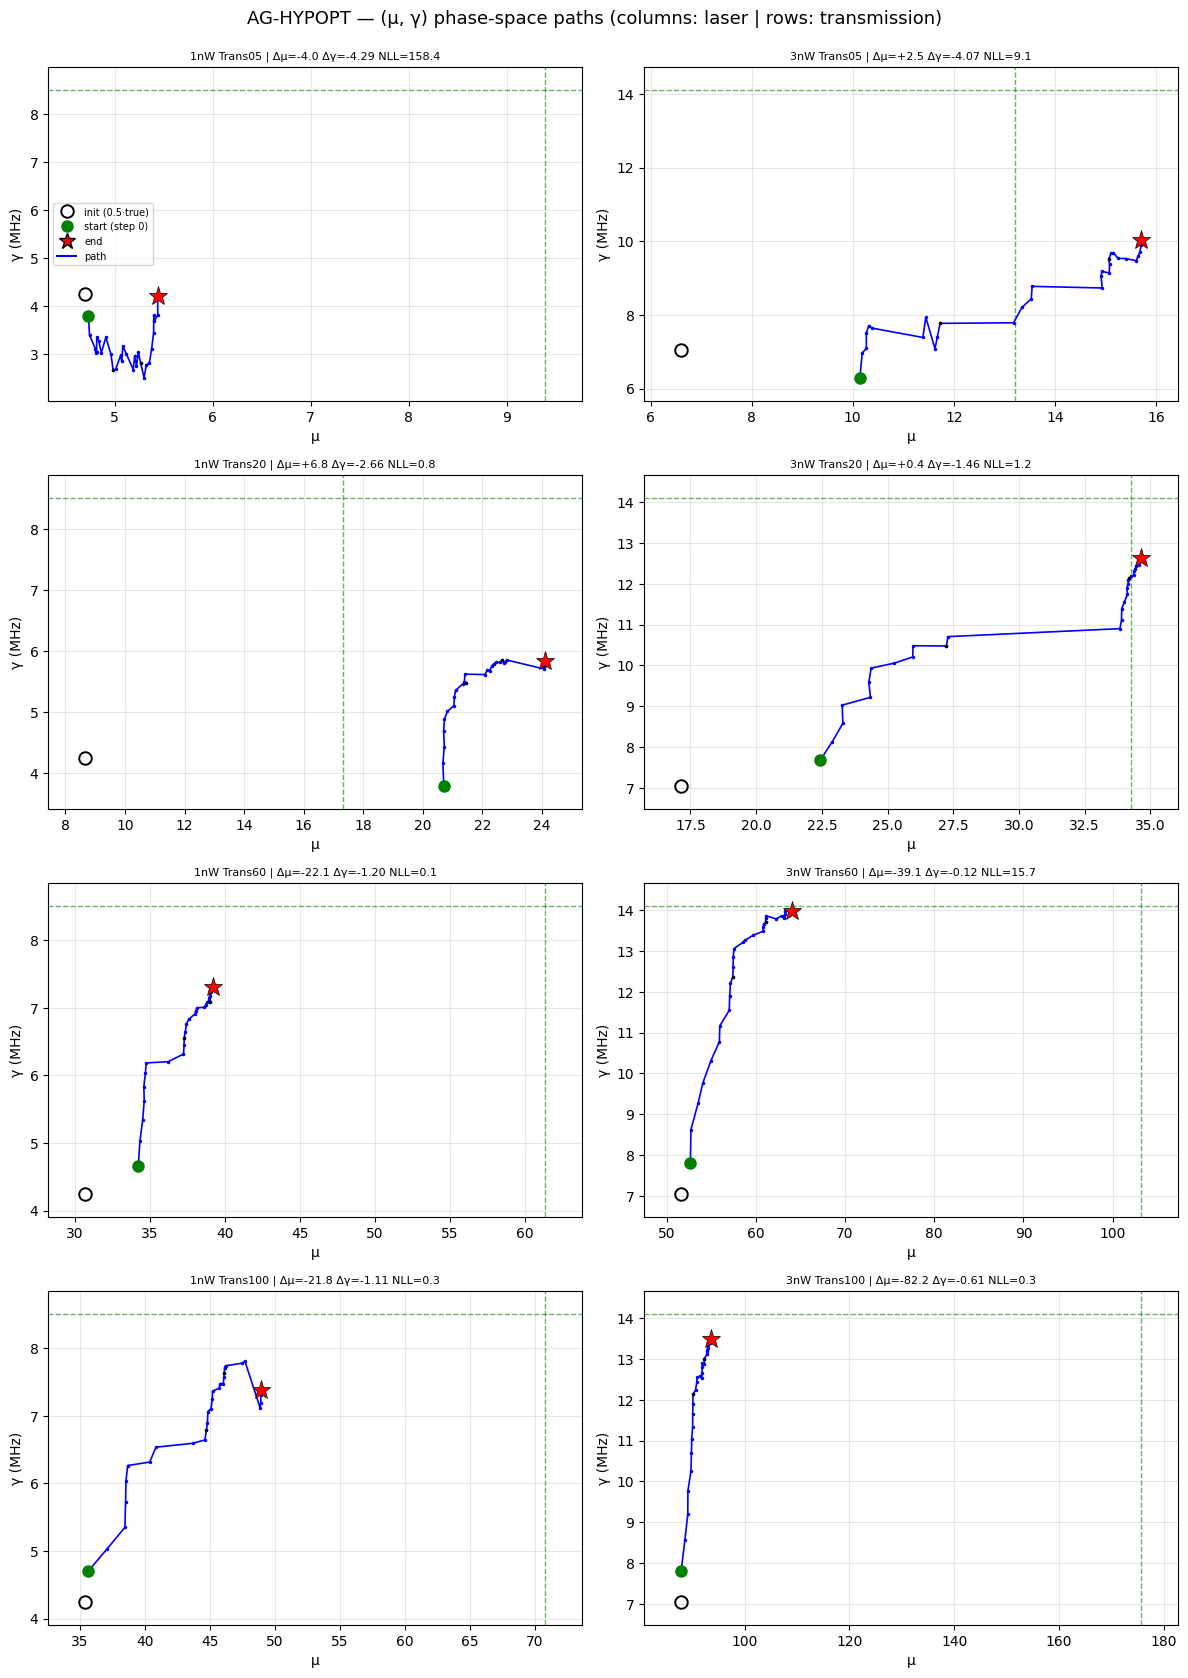

trial finished in 7.8 min
objective = 0.0840 ± 0.0207
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   24.11   +39.3 |     8.50    5.84   -31.3
1nW Trans60       61.37   39.22   -36.1 |     8.50    7.30   -14.1
1nW Trans100       70.82   48.97   -30.8 |     8.50    7.39   -13.1
3nW Trans05       13.20   15.70   +18.9 |    14.10   10.03   -28.8
3nW Trans20       34.28   34.66    +1.1 |    14.10   12.64   -10.4
3nW Trans60      103.20   64.07   -37.9 |    14.10   13.98    -0.9
3nW Trans100      175.71   93.55   -46.8 |    14.10   13.49    -4.4

weighted objective (T-graded, cap=1.0) = 0.0840 | diverged cells: 0
μ: RMSE 34.125 (rel 34.6%, bias -19.945) | γ: RMSE 2.429 (rel 24.6%, bias -1.941)


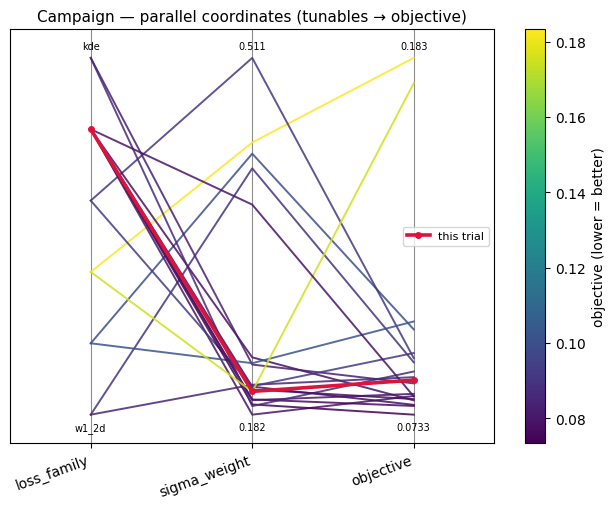

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.2030}` (candidate 3, top EI).
Trial time 7.8 min, objective **0.0840 +/- 0.0207**, **0 diverged cells**. This is the *worst* (highest)
`cvm_fwhm` draw to date and the **first** to land above the KDE control (0.0803).

**Basin scatter.** The `cvm_fwhm` series now spans sw 0.18-0.38 with nine points: 0.0733, 0.0760, 0.0764,
0.0777, 0.0781, 0.0790, 0.0791, 0.0798, 0.0840 -> mean ~0.0781, but with a spread (~0.004 std) larger
than earlier looked. So the family's edge over the control is small (~0.002 on the mean) and a single
trial can exceed the control.

**Per-cell behaviour.** The high-T gamma was a little worse than usual (1nW Trans100 -13.1 % vs the
typical -7 %; 3nW Trans60 NLL 15.74), which is where this run lost ground; low-count cells unchanged.

**Aggregates.** mu: RMSE 34.13 (rel 34.6 %), bias -19.95; gamma: RMSE 2.43 (rel 24.6 %), bias -1.94.

**Summary:** `cvm_fwhm` at sw 0.2030 gives 0.0840, its worst draw and the first above the KDE control,
showing the basin scatter is larger than first estimated and the mean edge is only ~0.002.
**Key insight:** The `cvm_fwhm` advantage is real on the mean (~0.078 over nine draws) but small and
comparable to seed noise, so the held-out validation is decisive for whether it is a true win.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: with a per-trial uncertainty of ~0.02 and a mean margin of ~0.002, the campaign's
`cvm_fwhm` win is suggestive, not significant on the benchmark alone; the held-out 6 are the real test.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm at sigma_weight 0.2030 gives 0.0840, its worst draw and the first above the KDE control, showing the basin scatter is larger than first estimated and the mean edge is only ~0.002.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The cvm_fwhm advantage is real on the mean (~0.078 over nine draws) but small and comparable to seed noise, so held-out validation is decisive.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_19 | current best: trial_13


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_20.ipynb. Open it and follow its cells from the top.
